# TinyGPT

**Author: Abraham R.**

The following notebook is an example of a really tiny GPT based model called TinyGPT.
You'll review the GPT architecture (transformer decoder) and implement the following tasks:

## TinyGPT Architecture

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, this model consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek
- Mistral

## Tasks

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)

## Architecture:
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

## What to expect?

- You'll manage to understand a depth implementation of a GPT model.
- Implement a MoE Layer to create a state-of-the art GPT model.
- Explore decoding algorithms for text generation.


### NOTE

Tokenization is out of scope, we'll use a simple yet ineffective character-based tokenizer.


In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type
import httpx

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

## Trainer

In [2]:
"""
trainer

Author: Abraham Rodriguez \n

CreationDate: 24/5/2023
UpdateDate: 1/6/2025

This module provides utilities for training PyTorch models, including early stopping,
checkpointing, mixed precision support, and training/evaluation loops.

This module is heavily inspired on Huggingface's Trainer/Accelerate and Pytorch Lightning, for relevant docs read:
- https://docs.pytorch.org/docs/stable/amp.html
- https://huggingface.co/docs/accelerate/usage_guides/gradient_accumulation
- https://lightning.ai/docs/pytorch/stable/advanced/training_tricks.html
- https://pytorch-lightning.readthedocs.io/en/1.5.10/advanced/training_tricks.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html
- https://lightning.ai/docs/pytorch/1.6.5/common/checkpointing.html
"""
import copy
import numpy as np
import torch
from torch.utils.data.dataloader import DataLoader
from tqdm import tqdm
import os

import warnings
import functools

def deprecated(reason):
	"""
    Decorator to mark functions as deprecated. It will emit a warning when the function is used.

    Args:
        reason (str): The reason why the function is deprecated.
	"""
	def decorator(func):
		@functools.wraps(func)
		def wrapped(*args, **kwargs):
			warnings.warn(
				f"{func.__name__}() is deprecated: {reason}",
				category=DeprecationWarning,
				stacklevel=2
			)
			return func(*args, **kwargs)
		return wrapped
	return decorator


class EarlyStopping():
	"""
	EarlyStopping serves as a mechanism to check if the loss does not have a considerable change, this can help to prevent overfitting
	and reduce the number of epochs (training time).
	"""
	def __init__(self, patience:int=5, min_delta :float=0, restore_best_weights:bool=True):
		"""

		Class constructor, sets mechanism to a certain quantity of patience, and a defined min_delta,
		and the best weights of the trained model.

		:param patience : patience to stop
		:type patience : int

		:param min_delta : minimum difference between losses per epoch.
		:type min_delta : float

		:param restore_best_weights :  restore best model
		:type restore_best_weights : bool

		"""
		self.patience = patience
		self.min_delta = min_delta
		self.restore_best_weights = restore_best_weights
		self.best_model = None
		self.best_loss = None
		self.counter = 0
		self.status = ""

	def __call__(self, model:torch.nn.Module, val_loss: float):
		"""
		Excutes logic when calling EarlyStopping object e.g
		es = EarlyStopping(patience=5)
		es(model,val_loss)
		"""
		if self.best_loss is None:
			self.best_loss = val_loss
			self.best_model = copy.deepcopy(model)

		elif self.best_loss - val_loss > self.min_delta:
			self.best_loss = val_loss
			self.counter = 0
			self.best_model.load_state_dict(model.state_dict())

		elif self.best_loss - val_loss < self.min_delta:
			self.counter += 1
			if self.counter >= self.patience:
				self.status = f"Stopped on {self.counter}"
				if self.restore_best_weights:
					model.load_state_dict(self.best_model.state_dict())
				return True

		self.status = f"{self.counter}/{self.patience}"
		return False

class Trainer():
	"""
	Custom trainer class that wraps model training and evaluation using PyTorch.

	This class supports:
	- Automatic Mixed Precision (AMP)
	- Gradient accumulation
	- Checkpointing during training
	"""
	def __init__(self,
			  	model : torch.nn.Module,
				train_data_loader: DataLoader,
				test_data_loader: DataLoader,
				loss_fn:torch.nn.Module,
				gradient_accumulation_steps :int,
				optimizer: torch.optim.Optimizer,
				scheduler: torch.optim.lr_scheduler.LRScheduler,
				device: str,
				save_dir : str = "./checkpoint",
				save_every_n = 1000
				):
		"""
        Initializes the Trainer class with the given model, data loaders, optimizer, and other training utilities.

        Args:
            model (torch.nn.Module): The model to train and evaluate.
            train_data_loader (DataLoader): DataLoader for the training dataset.
            test_data_loader (DataLoader): DataLoader for the test or validation dataset.
            loss_fn (torch.nn.Module): Loss function to optimize.
            gradient_accumulation_steps (int): Number of steps to accumulate gradients before updating weights.
            optimizer (torch.optim.Optimizer): Optimizer used to update model parameters.
            scheduler (torch.optim.lr_scheduler.LRScheduler): Learning rate scheduler.
            device (str): Device to run the model on ('cpu' or 'cuda').
			save_dir (str): checkpoint directory, defaults to"./checkpoint",
			save_every_step (int): save every N steps, defaults to 1000

        """
		self.model = model
		self.train_data_loader = train_data_loader
		self.test_data_loader = test_data_loader
		self.loss_fn = loss_fn
		self.optimizer = optimizer
		self.device = device
		self.gradient_accumulation_steps = gradient_accumulation_steps
		self.scheduler = scheduler
		self.save_dir = save_dir
		self.save_every = save_every_n

	def save_checkpoint(self, step: int, final=False):
		"""
		Saves a training checkpoint to disk, including model, optimizer, scheduler,
		and (if available) scaler state dictionaries.

		Args:
			step (int): The current training step or epoch number to include in the checkpoint.
			final (bool, optional): If True, saves the checkpoint as the final model.
									The filename will use 'final' instead of the step number.
									Default is False.

		Notes:
			- Checkpoints are saved under `self.save_dir` with a filename format:
				- `checkpoint_step_{step}.pt` for intermediate steps.
				- `checkpoint_final.pt` for the final checkpoint.
			- Includes `scaler_state_dict` only if `self.scaler` exists (used in AMP training).
			- Creates the save directory if it does not already exist.
		"""
		os.makedirs(self.save_dir, exist_ok=True)
		suffix = f"final" if final else f"step_{step}"
		path = os.path.join(self.save_dir, f"checkpoint_{suffix}.pt")
		torch.save({
			"model_state_dict": self.model.state_dict(),
			"optimizer_state_dict": self.optimizer.state_dict(),
			"scaler_state_dict": self.scaler.state_dict() if hasattr(self, "scaler") else None,
			"scheduler_state_dict": self.scheduler.state_dict(),
			"step": step
		}, path)

	@deprecated("Use train_model_v2 for pretraining due to efficiency")
	def train_model(self,use_amp = False, dtype : torch.dtype = torch.bfloat16):

		model = self.model.train()
		scaler = torch.amp.GradScaler(enabled=use_amp)
		losses = []
		bar = tqdm(self.train_data_loader)
		for train_input, train_mask in bar:
				train_mask = train_mask.to(self.device)
				train_input=train_input.to(self.device)
				with torch.autocast(device_type=self.device, dtype=dtype, enabled=use_amp):
					output = model(train_input)
					loss = self.loss_fn(output, train_mask)
				if isinstance(dtype, type(torch.float16)):
					scaler.scale(loss).backward()
					scaler.step(self.optimizer)
					scaler.update()
				else:

					loss.backward()
					self.optimizer.step()

				# outputs=model(train_input.float())
				# loss = loss_fn(outputs.float(), train_mask.float())
				losses.append(loss.item())
				#loss.backward()
				#optimizer.step()
				#optimizer.zero_grad()
				for param in model.parameters():
					param.grad = None
				bar.set_description(f"loss {loss:.5f}")
		return np.mean(losses)


	def train_model_v2(self, use_amp: bool = False, dtype: torch.dtype = torch.bfloat16):
		"""
			Efficient training loop with optional Automatic Mixed Precision (AMP) support and gradient accumulation.

			This method performs one full pass over the training dataset using the given data loader.
			It supports Automatic Mixed Precision (AMP) training, gradient clipping, and gradient accumulation
			to handle larger effective batch sizes.

			Args:
				use_amp (bool, optional): If True, enables Automatic Mixed Precision (AMP) training.
										Default is False.
				dtype (torch.dtype, optional): The floating point precision to use when AMP is enabled.
											Common options include `torch.float16` or `torch.bfloat16`.
											Default is `torch.bfloat16`.

			Returns:
				float: The average of the last 10 training loss values.

			Notes:
				- Gradients are clipped to a maximum L2 norm of 1.0 to improve stability.
				- Gradients are accumulated across `self.gradient_accumulation_steps` batches before stepping.
				- At the end of training, a checkpoint is saved and CUDA memory is cleared.

			Raises:
				RuntimeError: If CUDA is not available while AMP is requested.
			"""
		model = self.model.train()
		scaler = torch.amp.GradScaler(device=self.device,enabled=use_amp)
		losses = []
		accumulation_count = 0
		global_step = 0
		bar = tqdm(self.train_data_loader)
		for train_input, train_mask in bar:

			train_mask = train_mask.to(self.device, non_blocking=True)
			train_input = train_input.to(self.device, non_blocking=True)
			with torch.autocast(device_type=self.device, dtype=dtype, enabled=use_amp):
				output = model(train_input)  # [B, T, vocab_size]
				B, T, C = output.shape
				loss = self.loss_fn(output.view(B * T, C), train_mask.view(B * T))
			loss_for_logging = loss.detach()
			loss = loss / self.gradient_accumulation_steps

			if use_amp and (dtype == torch.float16 or dtype == torch.bfloat16):
				scaler.scale(loss).backward()
			else:
				loss.backward()

			torch.nn.utils.clip_grad_norm_(model.parameters(), 1., norm_type=2)
			accumulation_count += 1
			global_step += 1

			if accumulation_count % self.gradient_accumulation_steps == 0:
				if use_amp and dtype == torch.float16:
					scaler.step(self.optimizer)
					scaler.update()
				else:
					self.optimizer.step()
				self.optimizer.zero_grad(set_to_none=True)
				self.scheduler.step()
				accumulation_count = 0

			losses.append(loss_for_logging)

			if len(losses) % 10 == 0:
				bar.set_description(f"loss {torch.mean(torch.stack(losses[-10:])).item():.5f}")

		# Final step if not aligned with accumulation
		if accumulation_count != 0:
			if use_amp and dtype == torch.float16:
				scaler.step(self.optimizer)
				scaler.update()
			else:
				self.optimizer.step()
			self.optimizer.zero_grad(set_to_none=True)
			self.scheduler.step()

		self.save_checkpoint(global_step, final=True)
		torch.cuda.empty_cache()
		return torch.mean(torch.stack(losses[-10:])).item()


	def eval_model(self):
		"""
		Evaluates the model on the test dataset.

		This method switches the model to evaluation mode, disables gradient computation,
		and computes the average loss over the test dataset.

		A progress bar is displayed using `tqdm` to show validation loss in real time.

		Returns:
			float: The mean loss over the entire test dataset.
		"""
		model = self.model.eval()

		losses = []
		bar = tqdm(self.test_data_loader)
		with torch.no_grad():
			for val_input, val_mask in bar:

				val_mask = val_mask.to(self.device)
				val_input = val_input.to(self.device)
				outputs = model(val_input)  # [B, T, vocab_size]
				B, T, C = outputs.shape
				loss = self.loss_fn(outputs.view(B * T, C), val_mask.view(B * T))

				losses.append(loss.item())
				bar.set_description(f"val_loss {loss:.5f}")

		return np.mean(losses)

## Downloading Dataset

In [3]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

text = text[:100_000]  # Using 100k characters for speedup
print(text)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Character-based encoding

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])
data = torch.tensor(encode(text), dtype=torch.long)

# Train/test split
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

# Dataloaders

In [5]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# GPT Configuration

In [6]:
@dataclass
class MoEArgs():
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    num_experts_per_token : int = field(default=2)

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 8
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 8, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 61, 'bias': True, 'ff_class': None, 'moe': None}


In [7]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8,
                        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [8]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

        # Combined QKV projection
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [10]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## TinyGPT Architecture

In [11]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits


## Generation function (inference)

In [12]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Setup

In [13]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
m = TinyGPT(config).to(device)
model = torch.compile(m)

In [14]:
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 10

# Training

In [15]:
# Trainer instance
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/11246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
W0405 00:45:38.112000 39810 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/

Epoch 1 training loss: 2.0861


  0%|          | 0/1246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
val_loss 2.01672: 100%|██████████| 1246/1246 [00:09<00:00, 129.84it/s]


Epoch 1 validation loss: 2.0464


loss 2.16480: 100%|██████████| 11246/11246 [03:07<00:00, 60.12it/s]


...

Epoch 9 validation loss: 2.0464


loss 2.09724: 100%|██████████| 11246/11246 [03:07<00:00, 60.00it/s]


Epoch 10 training loss: 2.1006


val_loss 2.01672: 100%|██████████| 1246/1246 [00:09<00:00, 126.30it/s]


Epoch 10 validation loss: 2.0464
Training complete.


### Quick test

In [16]:
generate("To be", max_new_tokens=100,use_cache=True)

'To bense all.\n\nMANUS:\nHome lalediol cemives\nVO \nAnt.\n\nAUS:\nmin me theond thighsir ivenat id\nFowh the bee,'

### Guardado del modelo

In [42]:
torch.save(model.state_dict(), 'model.pth')

# Task I

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.


## Referencias

`Hugging Face - Generate function`
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation).


`Greedy decoding`
- [Definición](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig.do_sample): No tiene un parámetro directo, sino que se aplica cuando [do_sample](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig.do_sample) es *False*.
- [Implementación](https://github.com/huggingface/transformers/blob/v5.3.0/src/transformers/generation/utils.py#L2779-L2785): corresponde a cuando *do_sample* es *False*.

`Temperature`
- [Definición](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig.temperature): El valor utilizado para modular las probabilidades del siguiente token. Por defecto es $1.0$.
- [Implementación](https://github.com/huggingface/transformers/blob/main/src/transformers/generation/logits_process.py#L284-L299).

`Top_k`
- [Definición](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig.top_k): El número de tokens de vocabulario con mayor probabilidad que se deben conservar. Por defecto es $50$.
- [Implementación](https://github.com/huggingface/transformers/blob/main/src/transformers/generation/logits_process.py#L573-L586).
  - Utiliza [torch.topk](https://docs.pytorch.org/docs/stable/generated/torch.topk.html).

`Top_p`
- [Definición](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig.top_p): Si se establece en un valor *float* < 1, solo se conservan para la generación el conjunto más pequeño de tokens más probables cuyas probabilidades sumadas alcancen el valor **top_p** o un valor superior. Por defecto es $1.0$.
- [Implementación](https://github.com/huggingface/transformers/blob/main/src/transformers/generation/logits_process.py#L509-L533).

## Detalles del entorno de desarrollo

Esta notebook se ejecutó en `Google Colab`, utilizando un runtime con [GPU Tesla T4](https://colab.research.google.com/github/d2l-ai/d2l-tvm-colab/blob/master/chapter_gpu_schedules/arch.ipynb).

Las características del entorno son:

- RAM: $12.7$ GB.
- GPU RAM: $15$ GB.
- Espacio disponible de Disco: $112.6$ GB.

## Generate V2 y otras funciones

### Top-K sampling function

Se define la función `apply_top_k` que permite aplicar **top_k sampling** a un tensor de **logits**.

Fuentes:
- [Hugging Face - Text Generation - top_K](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig.top_k).
- [Hugging Face - logits process](https://github.com/huggingface/transformers/blob/main/src/transformers/generation/logits_process.py#L573-L586): Implementación de `top_k` sampling de Hugging Face.

Se utilizan las siguientes funciones:

- [torch.top_k](https://docs.pytorch.org/docs/stable/generated/torch.topk.html): dado unos **logits** y un **k**, devuelve los **k** mejores valores, junto a sus índices.
- [torch.full_like](https://docs.pytorch.org/docs/stable/generated/torch.full_like.html): dados un tensor y un valor, crea una copia de la misma dimensión del tensor, llenándola con el valor dado.
- [torch.Tensor.scatter_](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.scatter_.html): método asociado a los tensores de PyTorch. Reemplazan una serie de valores (`src`) dados en la posición (`index`) del tensor original.

De esta forma, la función `apply_top_k` realiza lo siguiente:

1. Obtiene los **k** mejores valores de los **logits**, junto a los índices.
1. Crea un nuevo tensor de misma dimensión que los **logits**, cuyos valores son todos -∞.
1. Reemplaza en el nuevo tensor los valores por aquellos **k** mejores valores del **logits** original.

In [17]:
def apply_top_k(logits, k):
  val, idx = torch.topk(logits, k, dim=-1)

  filtered_logits = torch.full_like(logits, float("-inf"))

  filtered_logits.scatter_(dim=-1, index=idx, src=val)

  return filtered_logits

### Top-p (nucleus) sampling function

Se define la función `apply_top_p` que permite aplicar **top_p sampling** a un tensor de **logits**.

Fuentes:
- [Hugging Face - Text Generation - top_p](https://github.com/huggingface/transformers/blob/main/src/transformers/generation/logits_process.py#L509-L533): Implementación de `top_p` sampling de Hugging Face.

En este caso, se adapta la implementación de Hugging Face para `top_p` sampling, con unos pequeños cambios.

La función `apply_top_p` funciona de la siguiente manera:
1. Dados un tensor de **logits** y una probabilidad **p**, comienza ordenando los **logits** de manera ascendente.
1. Calcula las probabilidades acumuladas del tensor de **logits** ordenado.
1. Luego, obtiene los índices para remover del tensor ordenado. Estos son aquellos cuya probabilidad acumulada es menor o igual a $1-p$. Se asegura de quedarse por lo menos un índice, de modo que no "borre" todo el tensor.
1. En el siguiente paso obtiene los índices a remover del tensor original.
1. Finalmente, copia al tensor original de **logits**, pero poniendo un valor de -∞ en los índices a eliminar.

In [18]:
def apply_top_p(logits, p):

  sorted_logits, sorted_indices = torch.sort(logits, descending=False)
  cumulative_probs = sorted_logits.softmax(dim=-1).cumsum(dim=-1)

  sorted_indices_to_remove = cumulative_probs <= (1 - p)
  sorted_indices_to_remove[..., 1 :] = 0

  indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
  scores_processed = logits.masked_fill(indices_to_remove, -float('inf'))
  return scores_processed

### generateV2 function

A diferencia de la función `generate()`, posee los siguientes parámetros:

- `model`: Modelo sobre el cual se trabaja.
- `temperature`: *float*. Indica la **temperatura** a utilizar. Si el valor es igual a $0$, implementa **Greedydecoding**. Por defecto es $1.0$.
- `top_k`: *int*, opcional. Permite implementar **top k** sampling, o elegir los mejores **k** siguientes tokens más probables. Por defecto es **None**.
- `top_p`: *float*, opcional. Permite implementar **top p** sampling, o elegir los siguientes tokens cuya probabilidad acumulada es al menos **p**. Por defecto es **None**.

**Cómo configurar Greedy decoding?**
- Opción 1: utilizar `temperature = 0.0`.
- Opción 2: utilizar `top_k = None` y `top_p = None`.

In [19]:
@torch.no_grad()
def generateV2(
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    model = None,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
)-> Optional[str]:

    if model is None:
      raise ValueError("Argument 'model' can not be None.")

    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        # Greedy Sampling:
        # Se aplica si la temperatura es 0
        # o si top_k y top_p son 0
        use_greedy = (temperature == 0.0 or (top_k is None and top_p is None))

        # Obtenemos el último token
        logits = logits[:, -1, :]

        if use_greedy:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # Aplico temperatura
            logits = logits / temperature

            if top_k is not None and top_k > 0:
              logits = apply_top_k(logits=logits, k=top_k)

            if top_p is not None and top_p < 1.0:
              logits = apply_top_p(logits=logits, p=top_p)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

## Compare generate vs generateV2

**NOTA**: se utiliza un modelo del tipo `TinyGPT` entrenado duranto $10$ épocas

### Resultados - Generate

A continuación se observa el resultado de la función `generate` con valores por defecto.

**Input**
```
To be
```

**Output**
```
To beided! I that ind a and he, tough
With whe is deardeds!

SICIUS:
To theange be
A fore hall, not to pi
```

In [78]:
result_gen = generate("To be", max_new_tokens=100,use_cache=True)

In [79]:
result_gen

'To beided! I that ind a and he, tough\nWith whe is deardeds!\n\nSICIUS:\nTo theange be\nA fore hall, not to pi'

### Resultados - Generate V2

#### Pruebas con Greedy search

**Caso 01**

Este es el resultado de la función `generateV2` al utilizar **Greedy decoding**. Para ello, se utiliza `temperature = 0.0`.

**Input**
```
To be
```

**Output**
```
To be the the the the the the the the the the the the the the the the the the the the the the the the the
```

In [83]:
result_genv2_greedy_01 = generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.0)

In [84]:
result_genv2_greedy_01

'To be the the the the the the the the the the the the the the the the the the the the the the the the the'

**Caso 02**

Este es el resultado de la función `generateV2` al utilizar **Greedy decoding**. Para ello, se utiliza `top_k = None` y `top_p = None`. `temperature` se configura en $1.0$.

**Input**
```
To be
```

**Output**
```
To be the the the the the the the the the the the the the the the the the the the the the the the the the
```

#### Pruebas con Temperature

**Caso 03**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $1.0$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To be wid will wither.
March toughs you wen of this athat youre stere in a treere warth.

MENENIUS:
And i
```

In [91]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=10, top_p=0.9)

'To be wid will wither.\nMarch toughs you wen of this athat youre stere in a treere warth.\n\nMENENIUS:\nAnd i'

**Caso 04**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $1.9$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To beack,
Te whown
By wn himse hee surts, has
Yhour streaver
At fllos is noffret
A hil be ang nret of ntu
```

In [92]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.9, top_k=10, top_p=0.9)

'To beack,\nTe whown\nBy wn himse hee surts, has\nYhour streaver\nAt fllos is noffret\nA hil be ang nret of ntu'

**Caso 05**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $5.0$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To besore's
BR atet wats tty,,y'Tildie hees; apesim!'trenc,'diess ndencly:
Is hamoly af
Oud our ore my te
```

In [93]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=5.0, top_k=10, top_p=0.9)

"To besore's\nBR atet wats tty,,y'Tildie hees; apesim!'trenc,'diess ndencly:\nIs hamoly af\nOud our ore my te"

**Caso 06**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $10.0$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To beesteried;,-at
Far yeletor
Weseichoou soodidleneanst:-alim;
O'lick wreeccut,''ly,' ned, flakn whelpp,
```

In [94]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=10.0, top_k=10, top_p=0.9)

"To beesteried;,-at\nFar yeletor\nWeseichoou soodidleneanst:-alim;\nO'lick wreeccut,''ly,' ned, flakn whelpp,"

**Caso 07**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $0.9$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To be sir bund,
We comen you the comer sone and the houldser whe hout ho that shave whis we so take, on h
```

In [95]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.9, top_k=10, top_p=0.9)

'To be sir bund,\nWe comen you the comer sone and the houldser whe hout ho that shave whis we so take, on h'

**Caso 08**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $0.75$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To bearst, shat would be hime the hour the patt he thou swill ing
And, be their the ast he wis mow owther
```

In [96]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.75, top_k=10, top_p=0.9)

'To bearst, shat would be hime the hour the patt he thou swill ing\nAnd, be their the ast he wis mow owther'

**Caso 09**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $0.5$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To be wore protes inglices the my cond the and then an the sto the a so do hour is shat shave and of of i
```

In [97]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.5, top_k=10, top_p=0.9)

'To be wore protes inglices the my cond the and then an the sto the a so do hour is shat shave and of of i'

**Caso 10**

En este caso se estudia el uso de `temperature` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `temperature` = $0.25$
- `top_k` = $10$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `temperature` se mantienen los mismos valores de `top_k` y `top_p`.

**Input**
```
To be
```

**Output**
```
To be the the the people of the hat the the he the the the the the shat his to the the the the a the the
```

In [98]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.25, top_k=10, top_p=0.9)

'To be the the the people of the hat the the he the the the the the shat his to the the the the a the the '

#### Pruebas con Top K

**Caso 11**

En este caso se estudia el uso de `top_k` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `top_k` = $5$
- `temperature` = $1.0$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `top_k` se mantienen los mismos valores de `temperature` y `top_p`.

**Input**
```
To be
```

**Output**
```
To be and thoures, to to hat whow heres tay,
Whim andle hus as whall, a here was hond, stand hiserve to t
```

In [126]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=5, top_p=0.9)

'To be and thoures, to to hat whow heres tay,\nWhim andle hus as whall, a here was hond, stand hiserve to t'

**Caso 12**

En este caso se estudia el uso de `top_k` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `top_k` = $25$
- `temperature` = $1.0$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `top_k` se mantienen los mismos valores de `temperature` y `top_p`.

**Input**
```
To be
```

**Output**
```
To bery, theirdid
Thave wing word. I hour
Annouch amm wath swand his the ich marme sts,
He moge tore uppe
```

In [112]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=25, top_p=0.9)

'To bery, theirdid\nThave wing word. I hour\nAnnouch amm wath swand his the ich marme sts,\nHe moge tore uppe'

**Caso 13**

En este caso se estudia el uso de `top_k` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `top_k` = $50$
- `temperature` = $1.0$
- `top_p` = $0.9$

**NOTA**: para las pruebas de `top_k` se mantienen los mismos valores de `temperature` y `top_p`.

**Input**
```
To be
```

**Output**
```
To beoshir fingooke, fry, shis hall homar his se iniden hush well bark., I I goe grith.

SICINIUS:
Benge
```

In [113]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=50, top_p=0.9)

'To be beare-be and uped ot;\nLe rove yourd ing let upler to lath, speah\nThe con or dime hen weart ows lalp'

#### Pruebas con Top P

**Caso 14**

En este caso se estudia el uso de `top_p` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `top_p` = $0.75$
- `temperature` = $1.0$
- `top_k` = $10$

**NOTA**: para las pruebas de `top_p` se mantienen los mismos valores de `temperature` y `top_k`.

**Input**
```
To be
```

**Output**
```
To be wortates of bat you he ave peate hond woutht hicgis
Our huth then thervat whird nows now so can te
```

In [114]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=10, top_p=0.75)

'To be wortates of bat you he ave peate hond woutht hicgis\nOur huth then thervat whird nows now so can te '

**Caso 15**

En este caso se estudia el uso de `top_p` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `top_p` = $0.5$
- `temperature` = $1.0$
- `top_k` = $10$

**NOTA**: para las pruebas de `top_p` se mantienen los mismos valores de `temperature` y `top_k`.

**Input**
```
To be
```

**Output**
```
To beir band be at him
Ongood you the and and ind afind hour ances,
Awe whe pould now of wantere,
Had it
```

In [115]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=10, top_p=0.5)

'To beir band be at him\nOngood you the and and ind afind hour ances,\nAwe whe pould now of wantere,\nHad it '

**Caso 16**

En este caso se estudia el uso de `top_p` en la función `generateV2`. Se utilizan los siguientes parámetros:

- `top_p` = $0.25$
- `temperature` = $1.0$
- `top_k` = $10$

**NOTA**: para las pruebas de `top_p` se mantienen los mismos valores de `temperature` y `top_k`.

**Input**
```
To be
```

**Output**
```
To be to dind, you them the ark the such of marie of mang he an supes
All ons meactius,
Witius at is woll
```

In [116]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=1.0, top_k=10, top_p=0.25)

'To be to dind, you them the ark the such of marie of mang he an supes\nAll ons meactius,\nWitius at is woll'

#### Otras pruebas

**Caso 17**

- `temperature` = $3.0$
- `top_k` = $50$
- `top_p` = $0.99$

**Input**
```
To be
```

**Output**
```
To be eitr?
EhkCDem,cfay f.
AWCGrR SjGok-d h'enchUbun ank ooy nql!
VOkh tity,Dy; gzak'u;
BaAcer'sp?ol-thv
```

In [117]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=3.0, top_k=50, top_p=0.99)

"To be eitr?\nEhkCDem,cfay f.\nAWCGrR SjGok-d h'enchUbun ank ooy nql!\nVOkh tity,Dy; gzak'u;\nBaAcer'sp?ol-thv"

**Caso 18**

- `temperature` = $0.5$
- `top_k` = $5$
- `top_p` = $0.50$

**Input**
```
To be
```

**Output**
```
To be the he a the mater the the so the winds of it them a the so the the so the with the the the than to
```

In [121]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.5, top_k=5, top_p=0.50)

'To be the he a the mater the the so the winds of it them a the so the the so the with the the the than to'

**Caso 19**

- `temperature` = $3$
- `top_k` = $5$
- `top_p` = $0.50$

**Input**
```
To be
```

**Output**
```
To berseent
The harcie so hice,
Ase and, aresstreanger, hir the wild,
Ans mor butiteng worde himen ones,
```

In [123]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=3.0, top_k=5, top_p=0.5)

'To berseent\nThe harcie so hice,\nAse and, aresstreanger, hir the wild,\nAns mor butiteng worde himen ones, '

**Caso 20**

- `temperature` = $0.5$
- `top_k` = $50$
- `top_p` = $0.99$

**Input**
```
To be
```

**Output**
```
To be him shave pationtion the whe for as the wouth, your cound their and would the the peop.

CORIOLUTUS
```

In [124]:
generateV2("To be", max_new_tokens=100,use_cache=True, model=model, temperature=0.5, top_k=50, top_p=0.99)

'To be him shave pationtion the whe for as the wouth, your cound their and would the the peop.\n\nCORIOLUTUS'

## Conclusiones - Task I

En esta tarea, se creó la función `generateV2`, una modificación de la función `generate` que permite aplicar:

- Greedy decoding: al seleccionar el token con mayor probabilidad.
- Temperature sampling.
- Top-K sampling.
- Top-P sampling.

Los resultados obtenidos en las distintas pruebas, que se pueden observar en la sección `Resultados - Generate V2`, muestran que la función `generateV2` NO genera oraciones coherentes. Esto puede deberse al "pequeño" tamaño del modelo, al tamaño de los datos de entrenamiento (**100k** caracteres), e incluso a la cantidad de épocas utilizadas durante el entrenamiento ($10$) en este caso.

Igualmente, se pueden observar los comportamientos de las distintas modificaciones al utilizar como `input` el texto **To be**:

**Greedy decoding**

- Las oraciones generadas consisten en una secuencia de artículos `the`.
- Si bien como oración NO tiene sentido, si es entendible desde el punto de vista de las palabras, ya que elige como token más probable a `the`, el cual es la "palabra" más usada en el inglés (ver [What Part of Speech Is the Word “The”?](https://www.grammarly.com/blog/parts-of-speech/the-part-of-speech/)).
- Ver sección `Pruebas con Greedy search`, **Caso 01** y **Caso 02**.

**Temperature**

- En este caso, las oraciones generadas también carecen de sentido, pero empiezan a tener cierta estructura.
- Se nota que, a mayor temperatura, los resultados tienden a tener términos más aleatorios.
  - Esto se puede ver en la sección `Pruebas con Temperature`, en los **Caso 03**, **Caso 04**, **Caso 05** y **Caso 06**.
  - Por ejemplo, en el **Caso 03** se usa una temperatura de $1.0$, la cual NO afecta a los logits (técnicamente, se hace $logits/temperature$), y los resultados tienen términos coherentes.
  - En cambio, en el caso **Caso 06** se utiliza una temperatura de $10$, y todos los términos son incoherentes.
- Se observa que, a menor temperatura, menos aleatoriedad, pero tiende a tener un comportamiento similar al **Greedy decoding**:
  - Esto se puede ver en la sección `Pruebas con Temperature`, en los **Caso 03**, **Caso 07**, **Caso 08**, **Caso 09** y **Caso 10**.
  - El **Caso 09** se usa una temperatura de $0.5$, y los términos que aparecen son menos aleatorios o incluso más conservadores que los que aparecen en el **Caso 03** (temperatura $1.0$).
  - Pero, se nota que en el **Caso 10**, con temperatura $0.25$, comienzan a repetirse términos, en este caso `the`, tal como sucede con **Greedy decoding**.
  - Esto tiene sentido, ya que una forma de implementar **Greedy decoding** es utilizando una temperatura de $0.0$. Es decir, a temperaturas cercanas a cero, el comportamiento será más cercano a un **Greedy decoding**.

**Top K sampling**

- En este caso, las oraciones generadas también carecen de sentido, pero empiezan a tener cierta estructura.
- Se nota que, a mayor valor de `k`, mayor cantidad de términos diferentes aparecen.
- Esto se debe a como funciona esta técnica de sampleo, la cual va eligiendo a los **k** mejores opciones/tokens, al ordenarlos por `logit`. Es decir, a un mayor **k**, mayor cantidad de opciones habrá.
- Esto se puede ver en la sección `Pruebas con Top K`, en los **Caso 11**, **Caso 12** y **Caso 13**.
- Por ejemplo, el **Caso 13** tiene términos que no aparecen en ninguno de los otros casos.

**Top P sampling**

- En este caso, las oraciones generadas también carecen de sentido, pero empiezan a tener cierta estructura.
- Se nota que, a menor **p**, menos términos diferentes aparecen.
- El motivo se debe a cómo funciona esta técnica, la cual va limitando las opciones/tokens en función de su probabilidad acumulada. Entonces, a menor **p**, menos opciones habrá.
- Esto se puede ver en la sección `Pruebas con Top P`, en los **Caso 14**, **Caso 15** y **Caso 16**.

# Task II
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

In [20]:
class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        ) ## Example network

    def forward(self, x) -> torch.Tensor:
        return self.net(x)

class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x):
        return self.proj(x)

In [21]:
# class MoELayer(nn.Module):
#     """
#     Mixture of experts FeedForward Layer
#     """

#     def __init__(self, experts : List[nn.Module], gate : nn.Module, moe_args : MoEArgs):
#         super().__init__()
#         self.experts = nn.ModuleList(experts)
#         self.gate = gate
#         self.args = moe_args

#     def forward(self, x : torch.Tensor) -> torch.Tensor:
#         return None

In [22]:
# Source: https://github.com/mistralai/mistral-inference/blob/main/src/mistral_inference/moe.py
class MoELayer(nn.Module):
    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        assert len(experts) > 0
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        gate_logits = self.gate(inputs)
        weights, selected_experts = torch.topk(gate_logits, self.args.num_experts_per_token)
        weights = F.softmax(weights, dim=1, dtype=torch.float).to(inputs.dtype)
        results = torch.zeros_like(inputs)
        for i, expert in enumerate(self.experts):
            # batch_idx, nth_expert = torch.where(selected_experts == i)
            coords = torch.where(selected_experts == i)
            batch_idx = coords[0]
            nth_expert = coords[1]
            results[batch_idx] += weights[batch_idx, nth_expert, None] * expert(inputs[batch_idx])
        return results

In [23]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe.num_experts)],
            gate=Gate(config),
            moe_args=config.moe
        )

    def forward(self, x):
        return self.moe(x)

## Adding MoE to Config

In [24]:
config = GPTConfig(
    block_size=32,
    batch_size=8,
    n_embd=64,
    n_head=4,
    n_layer=2,
    dropout=0.1,
    vocab_size=vocab_size,
    bias=True,
    ff_class=MoEFFN,
    moe=MoEArgs(num_experts=4, num_experts_per_token=1)
)

## Training TinyGPT-MoE


In [25]:
m_moe = TinyGPT(config).to(device)
model_moe = torch.compile(m_moe)

In [26]:
optimizer = AdamW(model_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 20

In [27]:
# Trainer instance
trainer = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/11246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
loss 2.77035: 100%|██████████| 11246/11246 [05:12<00:00, 35.95it/s]


Epoch 1 training loss: 2.7626


  0%|          | 0/1246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
val_loss 2.80241: 100%|██████████| 1246/1246 [00:13<00:00, 89.33it/s] 


Epoch 1 validation loss: 2.7024


loss 2.72326: 100%|██████████| 11246/11246 [05:15<00:00, 35.65it/s]


...

Epoch 19 validation loss: 2.7012


loss 2.72237: 100%|██████████| 11246/11246 [05:21<00:00, 34.99it/s]


Epoch 20 training loss: 2.7353


val_loss 2.81704: 100%|██████████| 1246/1246 [00:14<00:00, 85.87it/s]

Epoch 20 validation loss: 2.7018
Training complete.


### Guardado del modelo

In [44]:
torch.save(model_moe.state_dict(), 'model_moe.pth')

## Visualizing Attention

As we know, a GPT has the task to complete text, let's see the attention maps generated by a pretrained model

In [28]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Run forward with return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    # all_weights is a list of length n_layers
    # each element: shape (n_heads, batch_size, seq_len, seq_len)
    # We'll visualize the first batch element only

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()


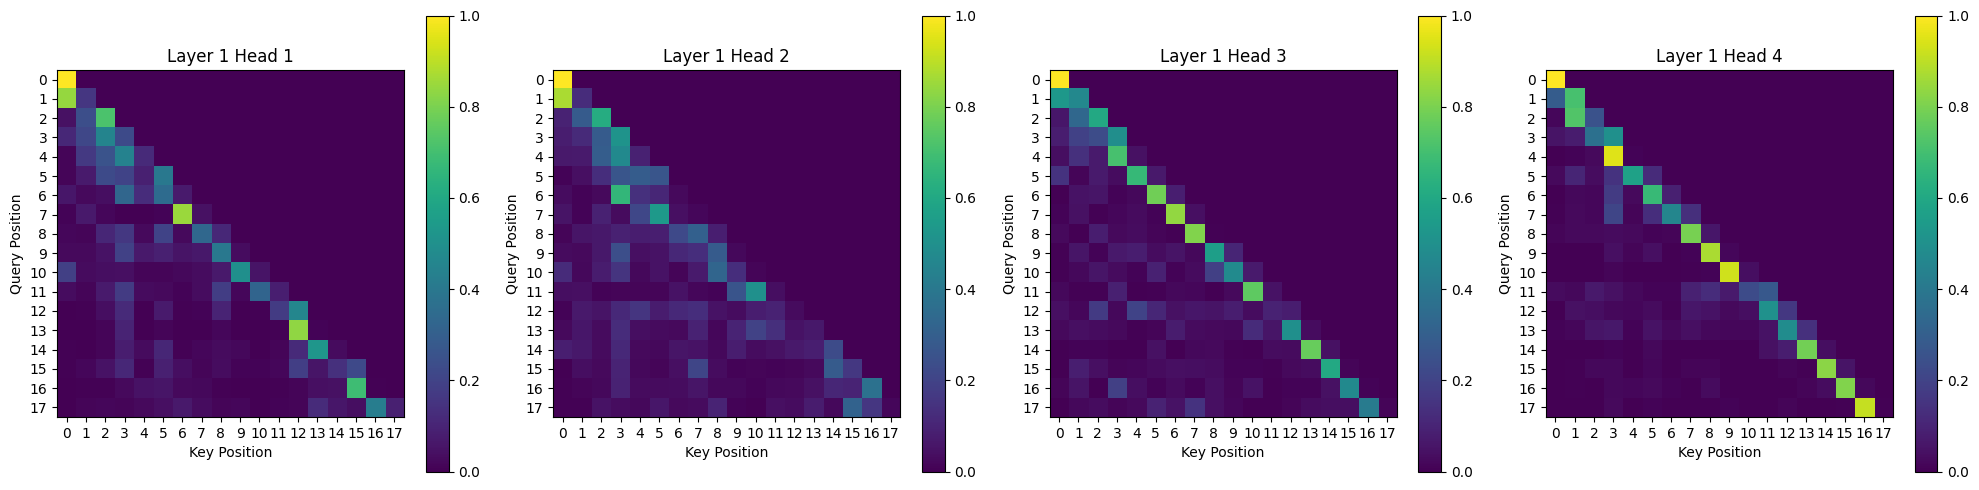

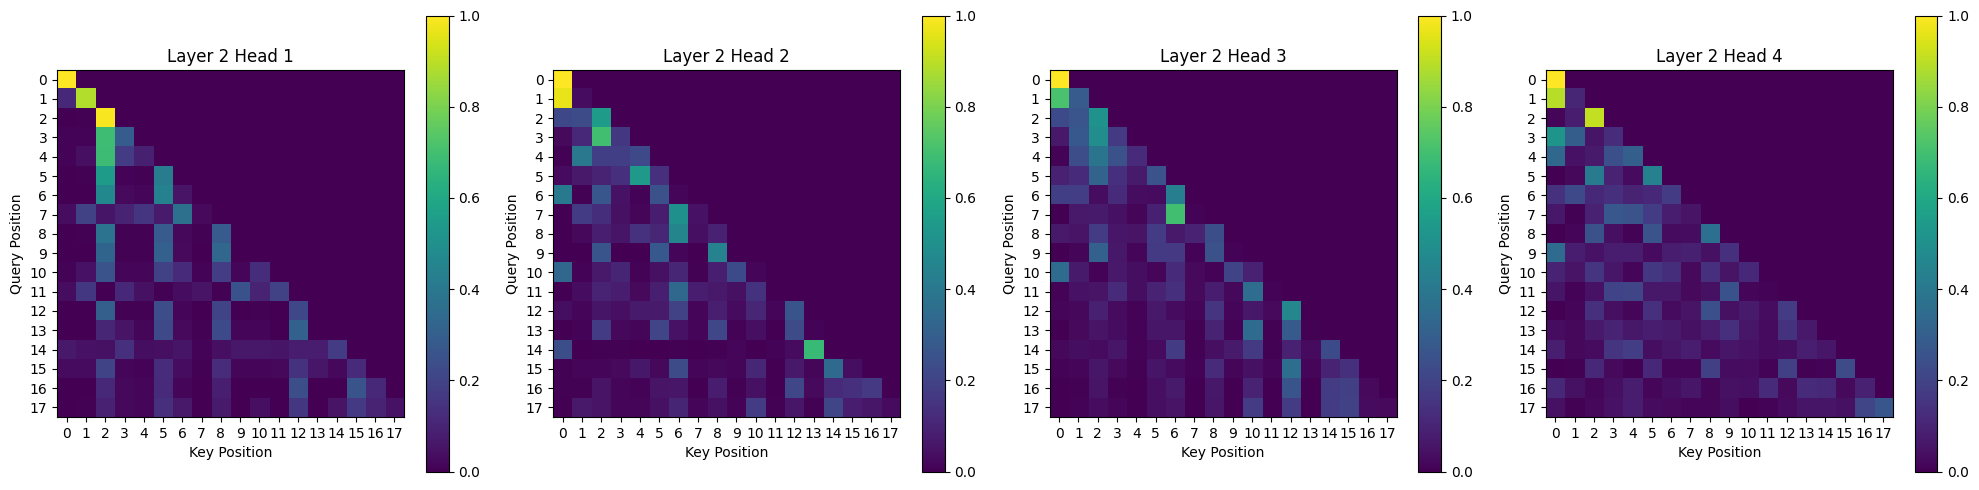

In [29]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

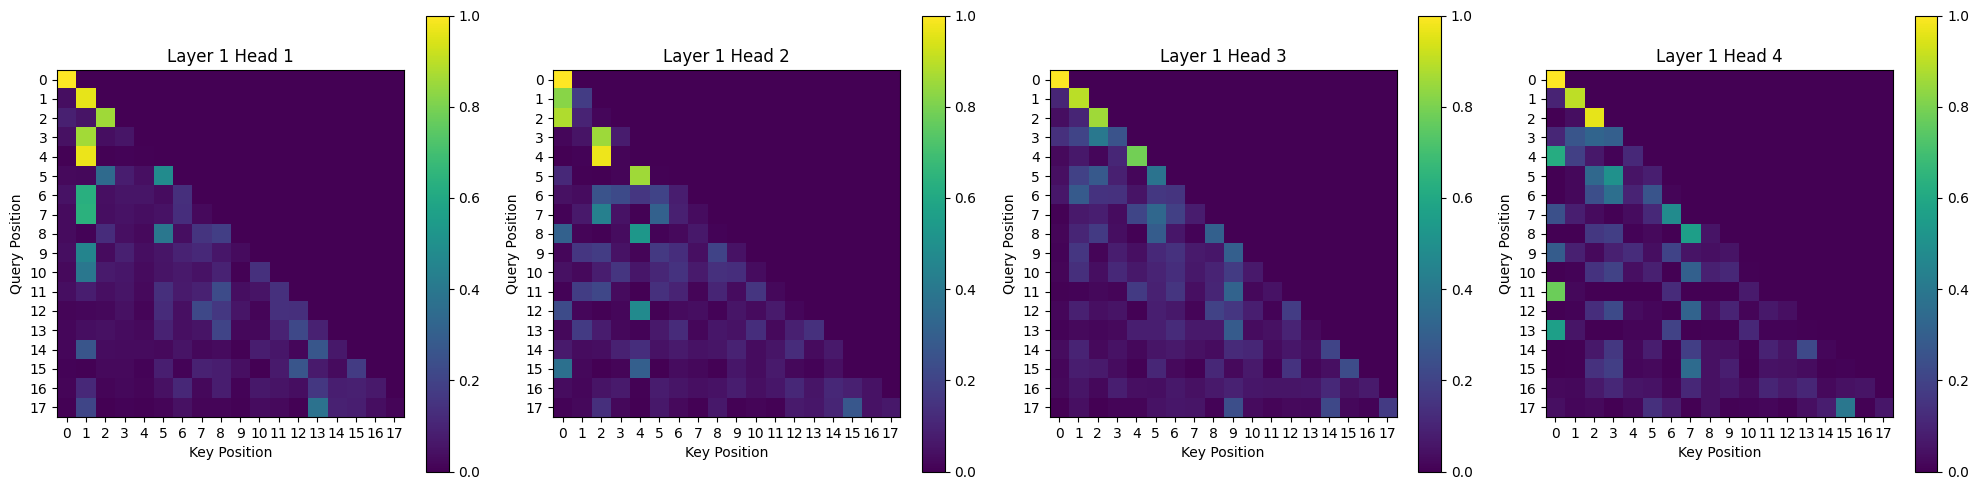

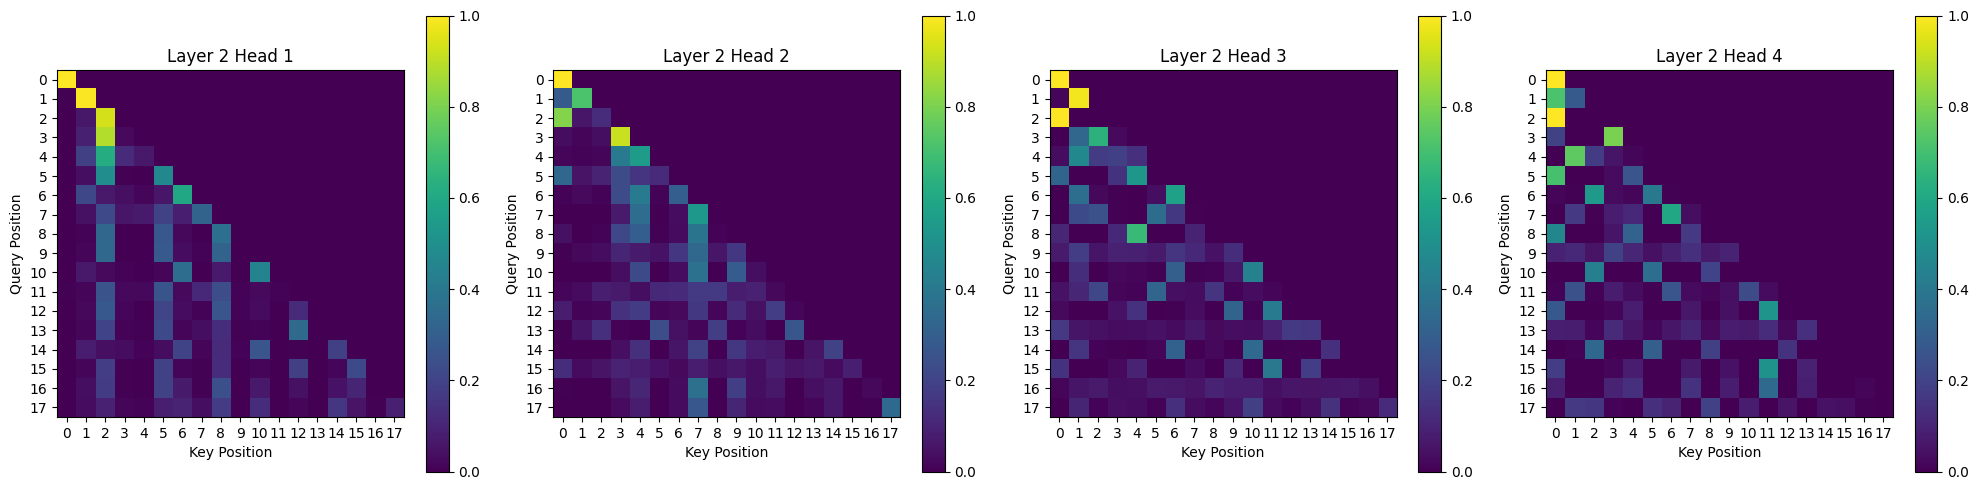

In [30]:
prompt = "To be or not to be"
visualize_attention(model_moe, prompt)

In [ ]:
## Para cargar un modelo, ejecutar:

# model = TinyGPT()
# state_dict = torch.load('model_weights.pth')
# model.load_state_dict(state_dict)
# model.eval()

In [43]:
## Para cargar un modelo, ejecutar:

# m_cargado = TinyGPT(config).to(device)
# model_cargado = torch.compile(m_cargado)
# state_dict = torch.load('model_moe.pth')
# model_cargado.load_state_dict(state_dict)
# model_cargado.eval()

# Conclusions

-
-

# Congratulations! 🎉

After completing the tasks you've successfully pretrained for first GPT, remember to add your conclusions and findings! And you can now brag to your friend on how LLMs and GPTs work!

